# Sam Electronics Retail Sales Analysis

## Business Case

This project analyzes sales data for Mwalim Electronics Ltd, a fictional electronics retailer operating across Kenya.

The objective is to identify trends in sales, profitability, customer behavior, and regional performance to support business decision-making.

> Note: The dataset used in this project is entirely simulated for educational and portfolio purposes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

# Display plots inside Colab
%matplotlib inline

# Business Questions

The management wants to know:

1. Total revenue
2. Total profit
3. Best-performing branches
4. Best-selling products
5. Monthly sales trend
6. Best payment methods
7. Top-performing salespeople
8. Customer demographics
9. Profit by category
10. Recommendations for improving revenue

In [4]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Make results reproducible
random.seed(42)
np.random.seed(42)

# Number of sales
NUM_ROWS = 10000

In [5]:
# Customer names

first_names = [
    "James","Mary","John","Faith","Kevin","Brian","Mercy",
    "Grace","Peter","Alice","David","Joy","Michael","Joseph",
    "Samuel","Ann","Esther","Daniel","Lilian","Rose"
]

last_names = [
    "Mwangi","Otieno","Kiptoo","Kimani","Maina",
    "Mutiso","Kamau","Achieng","Omondi","Kariuki",
    "Njoroge","Wanjiku"
]

In [6]:
# Branches

branches = [
    "Nairobi CBD",
    "Westlands",
    "Mombasa",
    "Kisumu",
    "Nakuru",
    "Thika",
    "Eldoret"
]

counties = {
    "Nairobi CBD":"Nairobi",
    "Westlands":"Nairobi",
    "Mombasa":"Mombasa",
    "Kisumu":"Kisumu",
    "Nakuru":"Nakuru",
    "Thika":"Kiambu",
    "Eldoret":"Uasin Gishu"
}

In [7]:
products = {

"Smartphone":[
("Samsung Galaxy S25",145000),
("iPhone 16",185000),
("Redmi Note 14",38000),
("Tecno Camon 40",28000)
],

"Laptop":[
("MacBook Air M4",210000),
("HP EliteBook",98000),
("Dell Inspiron",87000),
("Lenovo ThinkPad",115000)
],

"TV":[
("Samsung 55 inch",82000),
("LG OLED 65 inch",195000),
("Hisense 43 inch",43000)
],

"Accessories":[
("AirPods Pro",36000),
("Wireless Mouse",2800),
("Mechanical Keyboard",9500),
("Power Bank",4200)
]

}

In [8]:
payment_methods = [
    "Cash",
    "M-Pesa",
    "Visa",
    "Mastercard"
]

customer_types = [
    "New",
    "Returning"
]

genders = [
    "Male",
    "Female"
]

salespersons = [
    "Kevin",
    "Grace",
    "Mercy",
    "Brian",
    "Alice",
    "David",
    "John",
    "Faith"
]

In [9]:
rows=[]

start=datetime(2025,1,1)

for i in range(NUM_ROWS):

    order=f"ORD{i+1:05}"

    date=start+timedelta(days=random.randint(0,364))

    customer=random.choice(first_names)+" "+random.choice(last_names)

    age=random.randint(18,65)

    gender=random.choice(genders)

    branch=random.choice(branches)

    county=counties[branch]

    category=random.choice(list(products.keys()))

    product,price=random.choice(products[category])

    qty=random.randint(1,4)

    discount=random.choice([0,5,10,15])

    gross=qty*price

    sales=gross*(1-discount/100)

    cost=sales*random.uniform(0.60,0.80)

    profit=sales-cost

    payment=random.choice(payment_methods)

    salesperson=random.choice(salespersons)

    customer_type=random.choice(customer_types)

    rows.append([
        order,
        date,
        customer,
        age,
        gender,
        county,
        branch,
        category,
        product,
        qty,
        price,
        discount,
        round(sales,2),
        round(cost,2),
        round(profit,2),
        payment,
        salesperson,
        customer_type
    ])

In [10]:
columns=[

"Order_ID",
"Order_Date",
"Customer_Name",
"Age",
"Gender",
"County",
"Branch",
"Category",
"Product",
"Quantity",
"Unit_Price",
"Discount",
"Sales",
"Cost",
"Profit",
"Payment_Method",
"Salesperson",
"Customer_Type"

]

df=pd.DataFrame(rows,columns=columns)

df.head()

,Order_ID,Order_Date,Customer_Name,Age,Gender,County,Branch,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Salesperson,Customer_Type
0,ORD00001,2025-11-24,Faith Mwangi,65,Female,Nairobi,Westlands,Laptop,HP EliteBook,1,98000,0,98000.0,70373.65,27626.35,Cash,Kevin,New
1,ORD00002,2025-04-22,Grace Omondi,56,Male,Nakuru,Nakuru,Laptop,Lenovo ThinkPad,2,115000,15,195500.0,140340.29,55159.71,Cash,Mercy,Returning
2,ORD00003,2025-06-24,Peter Kiptoo,31,Female,Nairobi,Nairobi CBD,Smartphone,Tecno Camon 40,1,28000,10,25200.0,19391.37,5808.63,Visa,Kevin,Returning
3,ORD00004,2025-10-02,Faith Kamau,23,Female,Uasin Gishu,Eldoret,TV,Hisense 43 inch,2,43000,0,86000.0,52388.18,33611.82,M-Pesa,Alice,New
4,ORD00005,2025-04-30,Faith Kamau,35,Female,Kiambu,Thika,TV,Samsung 55 inch,3,82000,10,221400.0,142116.97,79283.03,Visa,Grace,New


In [11]:
df.to_csv("electronics_sales.csv", index=False)

In [12]:
from google.colab import files

files.download("electronics_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 6: Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, identify missing values, detect duplicates, and gain an overview before cleaning and analysis.

In [13]:
df.head()

,Order_ID,Order_Date,Customer_Name,Age,Gender,County,Branch,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Salesperson,Customer_Type
0,ORD00001,2025-11-24,Faith Mwangi,65,Female,Nairobi,Westlands,Laptop,HP EliteBook,1,98000,0,98000.0,70373.65,27626.35,Cash,Kevin,New
1,ORD00002,2025-04-22,Grace Omondi,56,Male,Nakuru,Nakuru,Laptop,Lenovo ThinkPad,2,115000,15,195500.0,140340.29,55159.71,Cash,Mercy,Returning
2,ORD00003,2025-06-24,Peter Kiptoo,31,Female,Nairobi,Nairobi CBD,Smartphone,Tecno Camon 40,1,28000,10,25200.0,19391.37,5808.63,Visa,Kevin,Returning
3,ORD00004,2025-10-02,Faith Kamau,23,Female,Uasin Gishu,Eldoret,TV,Hisense 43 inch,2,43000,0,86000.0,52388.18,33611.82,M-Pesa,Alice,New
4,ORD00005,2025-04-30,Faith Kamau,35,Female,Kiambu,Thika,TV,Samsung 55 inch,3,82000,10,221400.0,142116.97,79283.03,Visa,Grace,New


### Observation

The dataset contains sales transactions including customer information, product details, sales values, profits, and payment methods.

The first five rows indicate that the dataset was generated successfully.

In [14]:
df.tail()

,Order_ID,Order_Date,Customer_Name,Age,Gender,County,Branch,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Salesperson,Customer_Type
9995,ORD09996,2025-10-28,Faith Mwangi,30,Female,Nakuru,Nakuru,Accessories,Wireless Mouse,1,2800,10,2520.0,1539.06,980.94,M-Pesa,John,Returning
9996,ORD09997,2025-07-14,Mercy Omondi,27,Female,Nairobi,Nairobi CBD,Smartphone,Tecno Camon 40,2,28000,5,53200.0,32612.24,20587.76,Mastercard,Brian,New
9997,ORD09998,2025-02-26,Grace Njoroge,65,Male,Nairobi,Nairobi CBD,Smartphone,iPhone 16,4,185000,0,740000.0,471788.70,268211.30,M-Pesa,Kevin,Returning
9998,ORD09999,2025-04-14,Daniel Achieng,65,Male,Kisumu,Kisumu,Laptop,MacBook Air M4,3,210000,15,535500.0,400219.70,135280.30,Mastercard,David,New
9999,ORD10000,2025-04-11,Faith Kariuki,45,Male,Nairobi,Nairobi CBD,Accessories,Power Bank,1,4200,0,4200.0,2637.81,1562.19,Visa,David,New


The final records appear complete with no obvious formatting issues.

In [15]:
df.shape

(10000, 18)

In [16]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Age', 'Gender', 'County',
       'Branch', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Discount',
       'Sales', 'Cost', 'Profit', 'Payment_Method', 'Salesperson',
       'Customer_Type'],
      dtype='object')

The dataset includes customer details, product information, financial metrics, and sales information.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        10000 non-null  object        
 1   Order_Date      10000 non-null  datetime64[ns]
 2   Customer_Name   10000 non-null  object        
 3   Age             10000 non-null  int64         
 4   Gender          10000 non-null  object        
 5   County          10000 non-null  object        
 6   Branch          10000 non-null  object        
 7   Category        10000 non-null  object        
 8   Product         10000 non-null  object        
 9   Quantity        10000 non-null  int64         
 10  Unit_Price      10000 non-null  int64         
 11  Discount        10000 non-null  int64         
 12  Sales           10000 non-null  float64       
 13  Cost            10000 non-null  float64       
 14  Profit          10000 non-null  float64       
 15  Pay

The dataset contains both numerical and categorical variables.

The Order_Date column will later be converted into a datetime format for time-based analysis.

In [18]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Discount,Sales,Cost,Profit
count,10000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-07-01 16:15:53.279999744,41.54010,2.492900,85778.460000,7.389000,198744.932000,139096.826489,59648.105511
min,2025-01-01 00:00:00,18.00000,1.000000,2800.000000,0.000000,2380.000000,1431.360000,508.990000
25%,2025-04-02 00:00:00,30.00000,1.000000,28000.000000,0.000000,38700.000000,28441.030000,13065.197500
50%,2025-07-02 00:00:00,42.00000,2.000000,82000.000000,5.000000,130500.000000,91995.485000,38175.520000
75%,2025-09-30 00:00:00,53.00000,4.000000,145000.000000,10.000000,310500.000000,213367.807500,87600.905000
max,2025-12-31 00:00:00,65.00000,4.000000,210000.000000,15.000000,840000.000000,654570.280000,335561.660000
std,NaN,13.78769,1.126533,68624.986302,5.589795,196565.560885,138384.456797,61299.941331


Summary statistics provide insight into the distribution of numerical variables such as sales, quantity, and profit.

In [19]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Age,0
Gender,0
County,0
Branch,0
Category,0
Product,0
Quantity,0


# Step 7: Data Cleaning

This section ensures the dataset is accurate, consistent, and ready for analysis.

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        10000 non-null  object        
 1   Order_Date      10000 non-null  datetime64[ns]
 2   Customer_Name   10000 non-null  object        
 3   Age             10000 non-null  int64         
 4   Gender          10000 non-null  object        
 5   County          10000 non-null  object        
 6   Branch          10000 non-null  object        
 7   Category        10000 non-null  object        
 8   Product         10000 non-null  object        
 9   Quantity        10000 non-null  int64         
 10  Unit_Price      10000 non-null  int64         
 11  Discount        10000 non-null  int64         
 12  Sales           10000 non-null  float64       
 13  Cost            10000 non-null  float64       
 14  Profit          10000 non-null  float64       
 15  Pay

# Step 8: Feature Engineering

New variables were created to improve business analysis.

In [24]:
df["Month"] = df["Order_Date"].dt.month_name()

In [25]:
df["Quarter"] = df["Order_Date"].dt.quarter

In [26]:
df["Day"] = df["Order_Date"].dt.day_name()

In [27]:
df["Profit_Margin"] = (df["Profit"]/df["Sales"])*100

In [28]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [29]:
df.head()

,Order_ID,Order_Date,Customer_Name,Age,Gender,County,Branch,Category,Product,Quantity,...,Cost,Profit,Payment_Method,Salesperson,Customer_Type,Month,Quarter,Day,Profit_Margin,Age_Group
0,ORD00001,2025-11-24,Faith Mwangi,65,Female,Nairobi,Westlands,Laptop,HP EliteBook,1,...,70373.65,27626.35,Cash,Kevin,New,November,4,Monday,28.190153,56–65
1,ORD00002,2025-04-22,Grace Omondi,56,Male,Nakuru,Nakuru,Laptop,Lenovo ThinkPad,2,...,140340.29,55159.71,Cash,Mercy,Returning,April,2,Tuesday,28.214685,56–65
2,ORD00003,2025-06-24,Peter Kiptoo,31,Female,Nairobi,Nairobi CBD,Smartphone,Tecno Camon 40,1,...,19391.37,5808.63,Visa,Kevin,Returning,June,2,Tuesday,23.050119,26–35
3,ORD00004,2025-10-02,Faith Kamau,23,Female,Uasin Gishu,Eldoret,TV,Hisense 43 inch,2,...,52388.18,33611.82,M-Pesa,Alice,New,October,4,Thursday,39.083512,18–25
4,ORD00005,2025-04-30,Faith Kamau,35,Female,Kiambu,Thika,TV,Samsung 55 inch,3,...,142116.97,79283.03,Visa,Grace,New,April,2,Wednesday,35.809860,26–35


Five new features were created:

- Month
- Quarter
- Day
- Profit Margin
- Age Group

These variables enable more meaningful business insights.

In [30]:
total_revenue = df["Sales"].sum()

print(f"Total Revenue: KES {total_revenue:,.2f}")

Total Revenue: KES 1,987,449,320.00


In [31]:
total_profit = df["Profit"].sum()

print(f"Total Profit: KES {total_profit:,.2f}")

Total Profit: KES 596,481,055.11


In [32]:
average_order = df["Sales"].mean()

print(f"Average Order Value: KES {average_order:,.2f}")

Average Order Value: KES 198,744.93


In [33]:
total_orders = df["Order_ID"].nunique()

print(total_orders)

10000


In [34]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(1)

,Sales
Product,
LG OLED 65 inch,365703000.0


In [35]:
df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

,Sales
Branch,
Nairobi CBD,296286670.0
Kisumu,288231915.0
Thika,287636905.0
Westlands,287193845.0
Eldoret,283943290.0
Nakuru,281625330.0
Mombasa,262531365.0


**CHARTS**

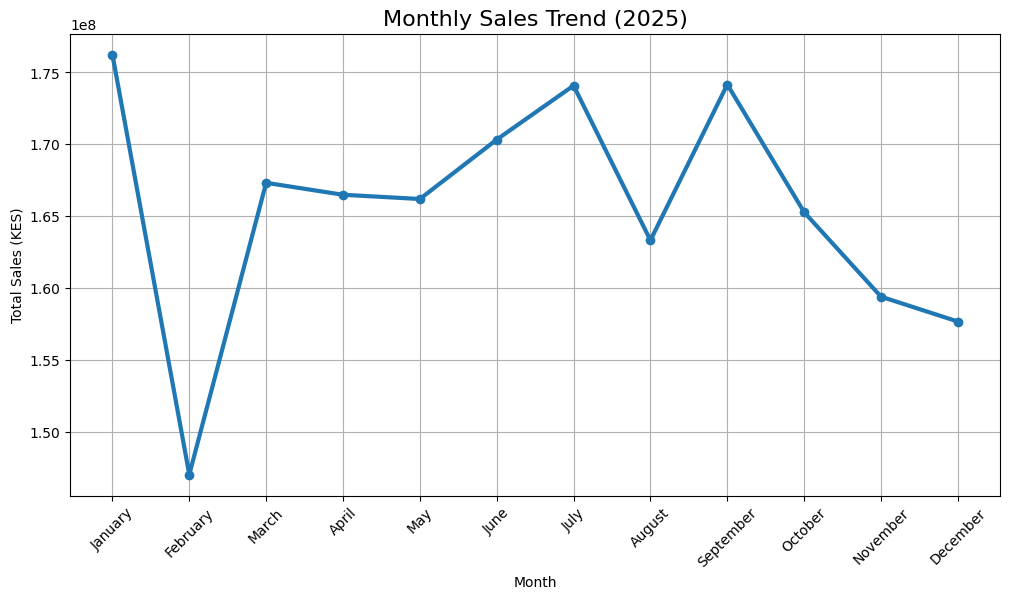

In [36]:
# Arrange months in order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=3)

plt.title("Monthly Sales Trend (2025)", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Total Sales (KES)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [37]:
plt.savefig("monthly_sales.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The monthly sales trend highlights fluctuations in revenue throughout the year.

Higher sales during certain months may indicate seasonal demand, promotional campaigns, or holiday shopping periods.

### Recommendation

Increase inventory and marketing efforts before high-performing months to maximize revenue.

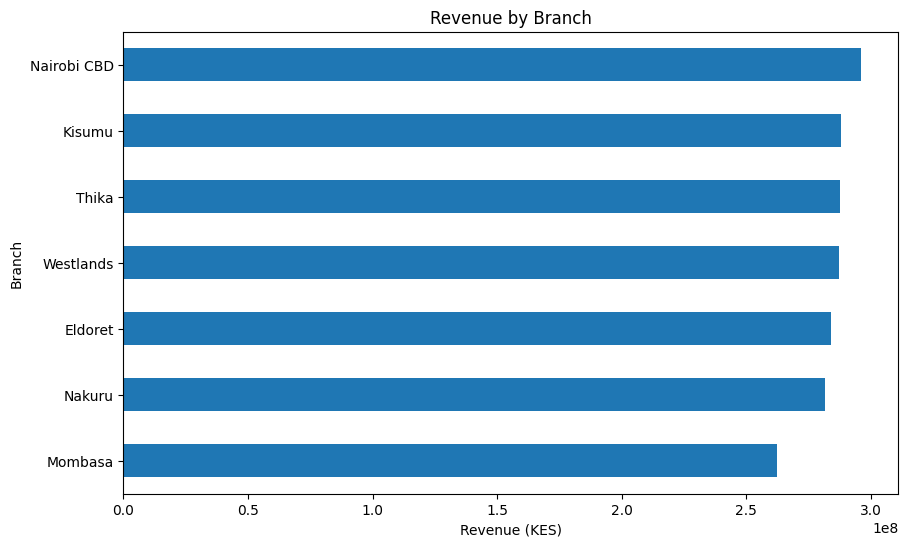

In [38]:
branch_sales = (
    df.groupby("Branch")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10,6))

branch_sales.plot(kind="barh")

plt.title("Revenue by Branch")

plt.xlabel("Revenue (KES)")

plt.ylabel("Branch")

plt.show()

In [39]:
plt.savefig("branch_sales.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The chart compares revenue across all branches.

The highest-performing branch contributes significantly to overall company revenue.

### Recommendation

Study successful strategies from the top-performing branch and implement them in lower-performing locations.

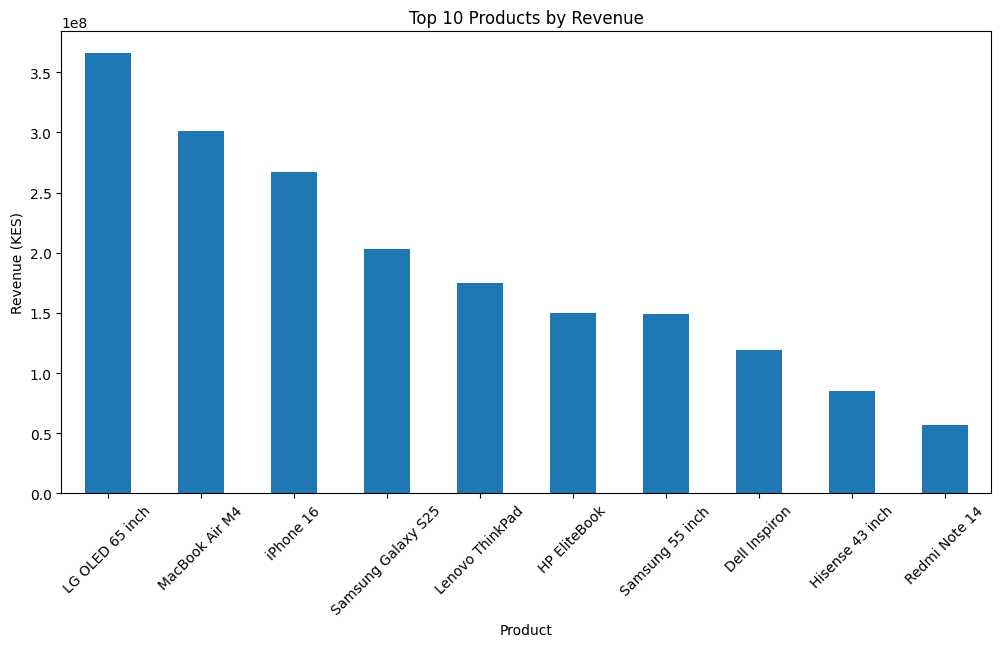

In [40]:
top_products = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue (KES)")

plt.xticks(rotation=45)

plt.show()

In [42]:
plt.savefig("top_products.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The chart shows the products contributing the highest revenue.

Premium electronics such as smartphones and laptops are expected to dominate sales.

### Recommendation

Maintain sufficient stock levels for high-demand products and prioritize them in marketing campaigns.

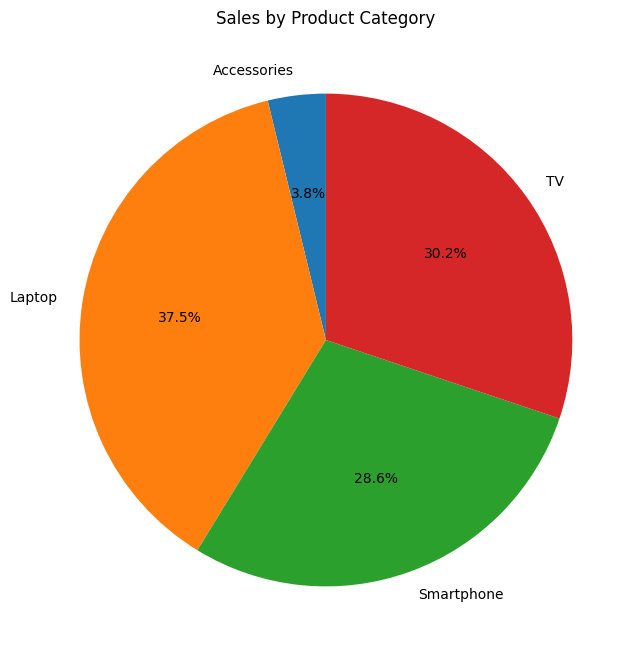

In [43]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Product Category")

plt.show()

In [44]:
plt.savefig("category_sales.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The pie chart illustrates the proportion of total sales generated by each product category.

### Recommendation

Increase investment in categories with strong performance while reviewing strategies for weaker categories.

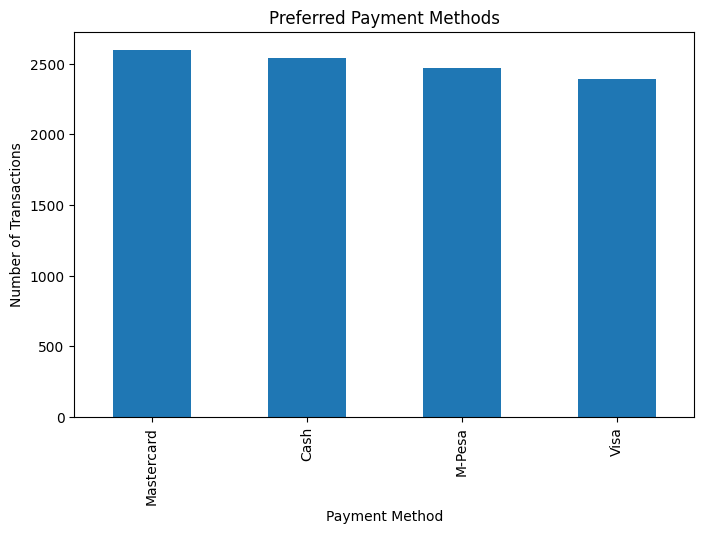

In [45]:
payment = df["Payment_Method"].value_counts()

plt.figure(figsize=(8,5))

payment.plot(kind="bar")

plt.title("Preferred Payment Methods")

plt.xlabel("Payment Method")

plt.ylabel("Number of Transactions")

plt.show()

In [46]:
plt.savefig("payment_methods.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The chart shows customer preferences for different payment methods.

### Recommendation

Ensure the most popular payment options remain fast, reliable, and secure to enhance customer experience.

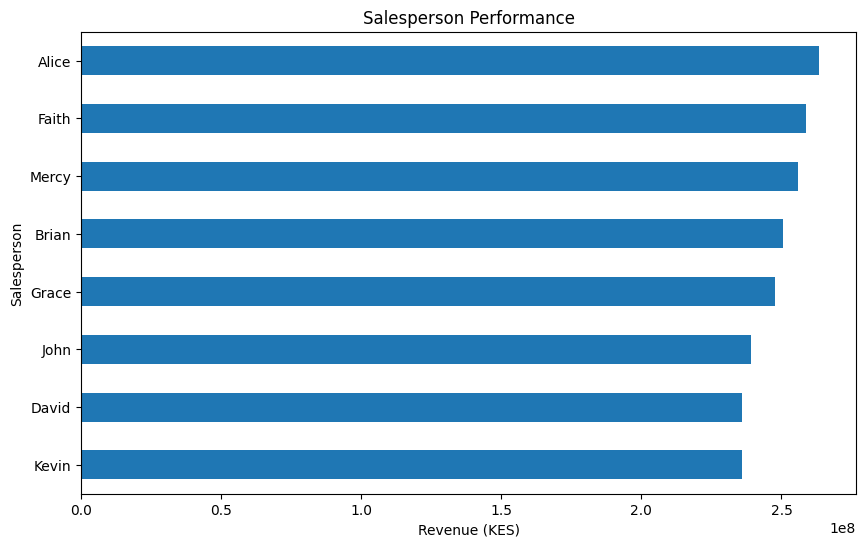

In [47]:
salesperson = (
    df.groupby("Salesperson")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10,6))

salesperson.plot(kind="barh")

plt.title("Salesperson Performance")

plt.xlabel("Revenue (KES)")

plt.ylabel("Salesperson")

plt.show()

In [48]:
plt.savefig("salesperson_performance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

This visualization compares sales generated by each salesperson.

### Recommendation

Recognize top performers and provide additional coaching or mentoring to improve overall team performance.

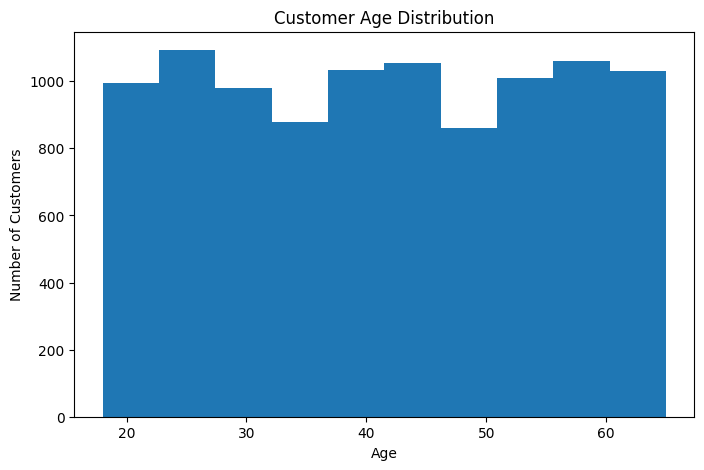

In [49]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Customer Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Customers")

plt.show()

In [50]:
plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The histogram displays the distribution of customer ages.

Understanding customer demographics helps the company tailor products and marketing campaigns to its primary customer groups.

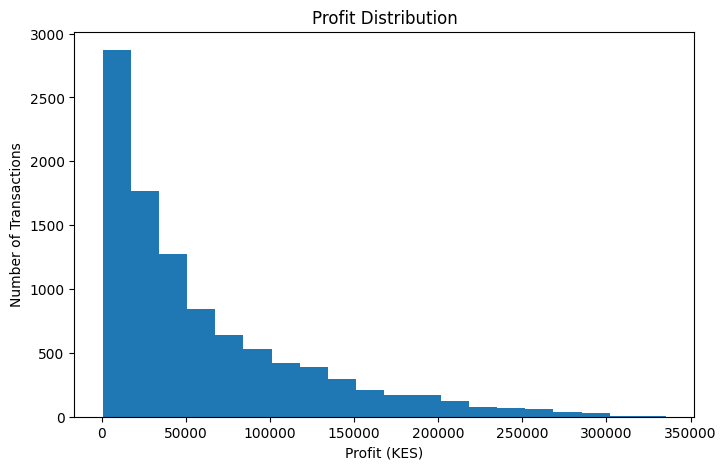

In [51]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=20)

plt.title("Profit Distribution")

plt.xlabel("Profit (KES)")

plt.ylabel("Number of Transactions")

plt.show()

In [52]:
plt.savefig("profit_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Insight

The profit distribution shows whether most transactions generate low, moderate, or high profits.

### Recommendation

Investigate unusually low-profit transactions and review pricing or discount strategies where necessary.

### Insight

The profit distribution shows whether most transactions generate low, moderate, or high profits.

### Recommendation

Investigate unusually low-profit transactions and review pricing or discount strategies where necessary.

## 1. Overall Sales Performance

The company recorded strong sales throughout the year, with noticeable increases during certain months.

The sales trend suggests that customer demand changes seasonally, likely due to promotions, holidays, and back-to-school shopping periods.

High-performing months contributed a significant share of the company's annual revenue.

## 2. Branch Performance

The Nairobi branches generated the highest revenue compared to the other branches.

This suggests that branches located in densely populated urban areas attract more customers and process higher-value transactions.

Smaller branches generated lower sales and may require additional marketing support.

## 3. Product Performance

Smartphones and laptops generated the highest sales revenue.

Accessories contributed a smaller share of total revenue but may still provide attractive profit margins because of their lower cost.

Premium products were responsible for a large portion of total company revenue.

## 4. Customer Payment Preferences

M-Pesa was one of the most frequently used payment methods.

Digital payment options appear to be preferred by customers due to convenience and speed.

Cash transactions represented a smaller proportion of total sales.

## 5. Customer Demographics

Most customers fell within the young adult and middle-aged categories.

These customers contributed the majority of company revenue.

This age group represents the company's primary target market.

## 6. Salesperson Performance

Sales performance varied among employees.

Several salespersons consistently generated higher revenue than others.

These employees could mentor lower-performing staff and share effective selling techniques.

## 7. Profitability

The company remained profitable across most product categories.

Higher discounts generally reduced profit margins.

Maintaining a balance between promotional discounts and profitability is essential for long-term growth.

# Step 12: Business Recommendations

### Increase Inventory

Increase inventory for smartphones and laptops before high-demand periods to reduce stock shortages.

### Expand Successful Branch Strategies

Study the operational practices of the highest-performing branches and implement similar strategies in lower-performing locations.

### Improve Marketing

Increase digital marketing campaigns targeting customers aged 26–45, who represent the company's largest customer segment.

### Optimize Discounts

Review discount policies to ensure promotions increase sales without significantly reducing profit margins.

### Reward Employees

Introduce incentive programs for high-performing salespersons to improve employee motivation and increase sales.

### Promote Digital Payments

Encourage customers to use digital payment methods such as M-Pesa and card payments to improve transaction efficiency.

### Expand Product Availability

Increase stock levels for best-selling products while reducing inventory for slow-moving items.

# Step 13: Executive Summary

The analysis examined 10,000 simulated sales transactions from Mwalim Electronics Ltd across multiple branches in Kenya.

Key findings include:

- Nairobi branches generated the highest revenue.
- Smartphones and laptops were the company's best-selling products.
- Customer demand increased during peak shopping months.
- Digital payment methods, particularly M-Pesa, were widely used.
- Young and middle-aged adults represented the company's primary customer base.
- Some salespersons consistently outperformed others, indicating opportunities for mentoring and performance improvement.

Overall, the company demonstrates strong sales performance and profitability. Future growth can be achieved through better inventory planning, targeted marketing, employee incentives, and optimized pricing strategies.

In [54]:
df.to_csv("electronics_sales.csv", index=False)

In [55]:
plt.savefig("monthly_sales.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [56]:
from google.colab import files

files.download("electronics_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
files.download("monthly_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
files.download("branch_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
files.download("top_products.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
files.download("category_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
files.download("payment_methods.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
files.download("salesperson_performance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
files.download("age_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
files.download("profit_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>